In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False)
X, y = fashion.data, fashion.target.astype(int)

In [3]:
rng = np.random.RandomState(42)
idx = rng.choice(len(X), 6000, replace=False)
X, y = X[idx] / 255.0, y[idx]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    start = time.time()
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k}: Accuracy={acc:.4f}, Time={elapsed:.2f}s")

K=1: Accuracy=0.7892, Time=0.46s
K=3: Accuracy=0.8075, Time=0.42s
K=5: Accuracy=0.8067, Time=0.35s
K=7: Accuracy=0.7983, Time=0.34s
K=9: Accuracy=0.7917, Time=0.40s
K=11: Accuracy=0.7950, Time=0.40s


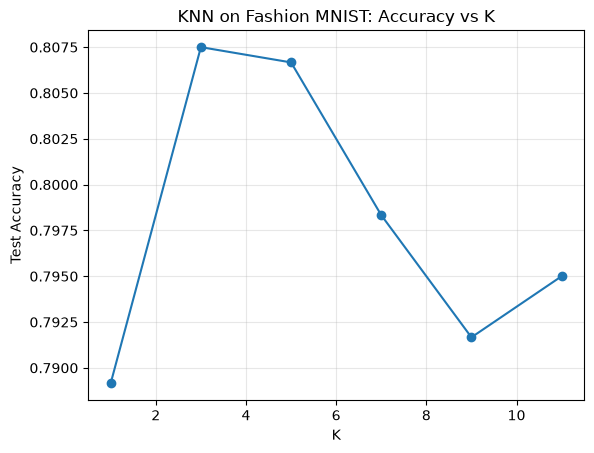

In [7]:
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("K")
plt.ylabel("Test Accuracy")
plt.title("KNN on Fashion MNIST: Accuracy vs K")
plt.grid(alpha=0.3)
plt.show()